In [10]:
%load_ext autoreload
%autoreload 2

from src.dynamical_systems import *
from src.SINDyModel import *
from src.derivatives import *
from src.helpers import *

import matplotlib.pyplot as plt
from tqdm import tqdm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
def generate_noise_level_vs_dt_matrix(rhs, x0, t_span, noise_levels, dts, threshold=0.05,
                                      generate_prediction=True, generate_more_derivatives=True):
    # we will return data as a 2d matrix of dictionaries
    # results[row][col] will be a dictionary of results for the test with dt=dts[row] and noise_level=noise_levels[col]

    # initialize the data matrix with None entries
    results = [[None for _ in range(len(noise_levels))] for _ in range(len(dts))]

    for i, dt in enumerate(dts):
        print(f"dt: {dt}")

        for j, noise_level in enumerate(tqdm(noise_levels)):
            result = {}

            # generate evaluation time points
            t_eval = np.arange(t_span[0], t_span[1] + dt, dt)
            result["t_eval"] = t_eval

            # generate training data
            x_train = generate_training_data(rhs, x0, t_eval)
            result["x_train"] = x_train
            
            # generate noisy data
            x_train_noisy = add_noise_to_data(x_train, noise_level)
            result["x_train_noisy"] = x_train_noisy

            # generate the derivative of the noisy data using finite difference
            x_dot_finite_difference = dxdt_finite_difference(x_train_noisy, t_eval)
            result["x_dot_finite_difference"] = x_dot_finite_difference

            # generate the true derivative of the data
            # this is only used for comparison and is not used in the SINDy model
            x_dot_true = rhs(0, x_train)
            result["x_dot_true"] = x_dot_true

            # generate different derivative approximations if needed
            if generate_more_derivatives is True:
                x_dot_poly_fit = dxdt_poly_fit(x_train_noisy, t_eval, poly_deg=3, window_diameter=5)
                result['x_dot_poly_fit'] = x_dot_poly_fit
            
            # create and fit a SINDy model
            model = SINDyModel(n_state_vars=len(x0), threshold=threshold, poly_order=5)
            model.fit(x_train_noisy, x_dot_poly_fit)
            result["model"] = model

            # generate the model prediction if needed
            if generate_prediction is True:
                x_pred = generate_model_prediction(model, x0, t_eval)
                result["x_pred"] = x_pred
            
            # store the data entry
            results[i][j] = result
        
    return results

In [12]:
lotka_volterra_rhs = generate_lotka_volterra_rhs(1, 0.1, 1.5, 0.75)

# noise_levels = [0, 0.0001, 0.001, 0.01, 0.05, 0.1, 0.2, 1]
# dts = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1]
noise_levels = np.logspace(-4, 0, 10).tolist()
dts = np.logspace(-2, 0, 11).tolist()

results = generate_noise_level_vs_dt_matrix(
    rhs=lotka_volterra_rhs,
    x0=(10, 5),
    t_span=(0, 50),
    noise_levels=noise_levels,
    dts=dts,
    generate_prediction=True,
    generate_more_derivatives=True,
)

dt: 0.01


 70%|███████   | 7/10 [00:10<00:04,  1.44s/it]c:\Elliot\docs\education\college\2024-2025\MS project\MS-project\src\SINDyModel.py:9: RuntimeWarning: overflow encountered in power
  return lambda x: np.prod(np.power(x, power_tuple), axis=1)
c:\Elliot\docs\education\college\2024-2025\MS project\MS-project\src\SINDyModel.py:141: RuntimeWarning: invalid value encountered in matmul
  x_dot = Theta @ self.Xi
c:\Users\Elliot\anaconda3\envs\ds312\Lib\site-packages\scipy\integrate\_ivp\lsoda.py:161: UserWarning: lsoda: Excess accuracy requested (tolerances too small).
  solver._y, solver.t = integrator.run(
100%|██████████| 10/10 [00:16<00:00,  1.67s/it]


dt: 0.015848931924611134


100%|██████████| 10/10 [00:11<00:00,  1.19s/it]


dt: 0.025118864315095794


...

100%|██████████| 10/10 [00:06<00:00,  1.60it/s]


dt: 0.6309573444801934


100%|██████████| 10/10 [00:05<00:00,  1.74it/s]


dt: 1.0


100%|██████████| 10/10 [00:13<00:00,  1.38s/it]


In [13]:
# make labels for use in the following heatmaps
xticklabels = [f"{dt:.3f}\n{i}" for i, dt in enumerate(dts)]
yticklabels = [f"{noise_level:.5f}\n{i}" for i, noise_level in list(enumerate(noise_levels))[::-1]]

In [14]:
# make a matrix of the relative coefficient errors

true_coeffs = generate_lotka_volterra_true_coefficients(1, 0.1, 1.5, 0.75)

rce_mtx = np.zeros((len(dts), len(noise_levels)))

for i in range(len(dts)):
    for j in range(len(noise_levels)):
        model = results[i][j]["model"]
        rce = relative_coefficient_error(true_coeffs, model.Xi)
        rce_mtx[i, j] = rce

# flip the matrices so that the smallest dt and noise level are in the bottom left corner
rce_mtx = rce_mtx[:, ::-1].T

In [15]:
# make a matrix of the relative trajectory errors

rte_mtx = np.zeros((len(dts), len(noise_levels)))

for i in range(len(dts)):
    for j in range(len(noise_levels)):
        x_train = results[i][j]["x_train"]
        x_pred = results[i][j]["x_pred"]

        # calculate the relative trajectory error
        # if the model prediction is "None", set the rte to np.nan
        if x_pred is None:
            rte = np.nan
        else:
            rte = relative_trajectory_error(x_train, x_pred)
        
        rte_mtx[i, j] = rte

# flip the matrices so that the smallest dt and noise level are in the bottom left corner
rte_mtx = rte_mtx[:, ::-1].T

[Text(0.5, 25.649999999999984, 'dt'),
 Text(59.64999999999999, 0.5, 'noise level'),
 Text(0.5, 1.0, 'Relative Trajectory Error')]

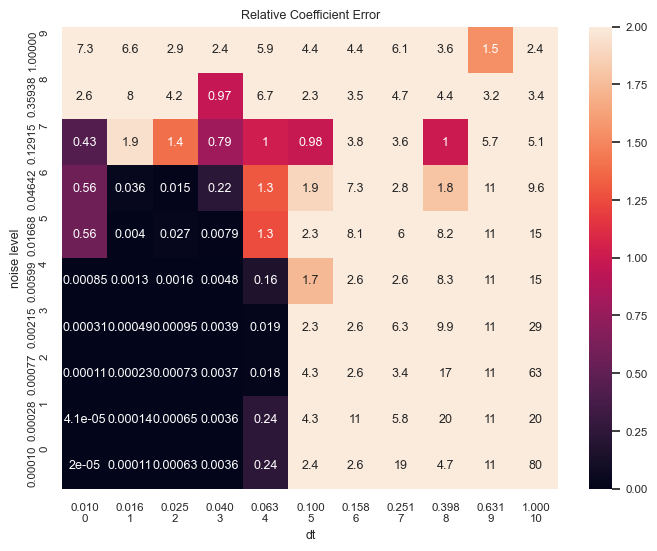

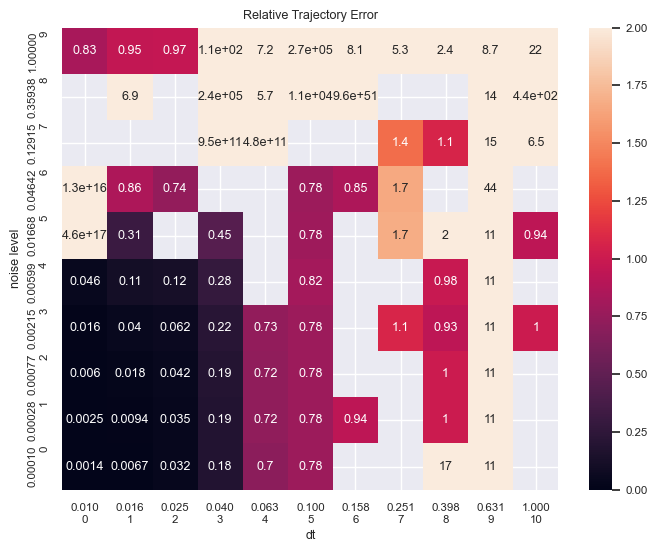

In [16]:
import seaborn as sns

sns.set_theme(font_scale=0.75)

fig = plt.figure(figsize=(8, 6))
ax = sns.heatmap(rce_mtx, annot=True, xticklabels=xticklabels, yticklabels=yticklabels, vmin=0, vmax=2)
ax.set(xlabel='dt', ylabel='noise level', title="Relative Coefficient Error")

fig = plt.figure(figsize=(8, 6))
ax = sns.heatmap(rte_mtx, annot=True, xticklabels=xticklabels, yticklabels=yticklabels, vmin=0, vmax=2)
ax.set(xlabel='dt', ylabel='noise level', title="Relative Trajectory Error")